# 🔍 Loser Autopsy Notebook

A systematic forensic analysis of why your trades fail. The goal is **not** to retrain a model — it's to understand the *failure modes* of your primary strategy so you can engineer features that capture them.

## 🎯 Outputs of This Notebook

By the end, you'll have:
1. **Quantitative profile** of losing vs winning trades across all features
2. **Statistical evidence** of which features actually discriminate
3. **Loser clusters** — types of failure patterns
4. **Regime diagnostics** — when does the strategy break down?
5. **Symbol/sector hotspots** — where do bad trades concentrate?
6. **Path analysis** — how do losers typically unfold?
7. **A ranked list of feature engineering ideas** with concrete code

## 📋 The Investigation Framework

```
       Hypothesize          Engineer        Validate
   ┌────────────┐      ┌────────────┐    ┌────────────┐
   │ "Losers    │ ───▶ │ Build new  │ ─▶ │ Add to     │
   │  happen    │      │ feature    │    │ meta-model │
   │  when X"   │      │ capturing  │    │ check AUC  │
   └────────────┘      │ X          │    │ improvement│
        ▲              └────────────┘    └─────┬──────┘
        │                                      │
        └──────────── iterate ─────────────────┘
```


# 1. Setup & Data Loading

In [2]:
import sys
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi']    = 100
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

try:
    notebook_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [3]:
# Load your existing training data (from meta-labeling notebook)
# This assumes you've saved closed_trades with features merged
# OR re-run cells 1-6 from train_models_meta_labeling.ipynb first

# Option A: Load from saved file
training_df = pd.read_hdf('all_trades_with_features.h5', 'data')

# Option B: Re-create from your pipeline (paste cells 1-6 from meta-labeling nb)
# For this autopsy we need:
#   - training_df with all features merged
#   - 'net_return' column
#   - 'Y' label
#   - 'entry_date', 'exit_date', 'symbol' columns

# === Quick sanity check ===
required_cols = ['symbol', 'entry_date', 'exit_date', 'net_return', 'Y']
assert all(c in training_df.columns for c in required_cols), \
    f"Missing columns. Need: {required_cols}"

print(f"Total trades: {len(training_df)}")
print(f"Date range:   {training_df['entry_date'].min()} → {training_df['entry_date'].max()}")
print(f"Symbols:      {training_df['symbol'].nunique()}")
print(f"Win rate:     {training_df['Y'].mean():.2%}")
print(f"Mean return:  {training_df['net_return'].mean():.3%}")

Total trades: 14296
Date range:   2017-02-06 00:00:00 → 2026-04-06 00:00:00
Symbols:      196
Win rate:     38.50%
Mean return:  2.860%


# 2. Loser Segmentation

Not all losers are created equal. A trade that lost -0.5% is fundamentally different from one that lost -10%. Let's segment them properly.


In [4]:
# === Segment trades by outcome severity ===
def segment_trades(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # Quantile-based segmentation of net returns
    q = df['net_return'].quantile([0.10, 0.30, 0.70, 0.90]).values
    
    def categorize(r):
        if   r <= q[0]: return '1_catastrophic_loss'  # bottom 10%
        elif r <= q[1]: return '2_medium_loss'         # 10-30%
        elif r <= q[2]: return '3_marginal'            # 30-70% (noise)
        elif r <= q[3]: return '4_medium_win'          # 70-90%
        else:           return '5_big_win'             # top 10%
    
    df['outcome'] = df['net_return'].apply(categorize)
    return df, q

training_df, return_quantiles = segment_trades(training_df)
print(f"Return quantile thresholds: 10%={return_quantiles[0]:.3%}, "
      f"30%={return_quantiles[1]:.3%}, 70%={return_quantiles[2]:.3%}, "
      f"90%={return_quantiles[3]:.3%}\n")

print(training_df.groupby('outcome').agg(
    count=('net_return', 'count'),
    mean_return=('net_return', 'mean'),
    median_return=('net_return', 'median'),
    std_return=('net_return', 'std'),
).round(4))

Return quantile thresholds: 10%=-9.225%, 30%=-4.658%, 70%=3.027%, 90%=19.000%

                     count  mean_return  median_return  std_return
outcome                                                           
1_catastrophic_loss   1430      -0.1335        -0.1196      0.0417
2_medium_loss         2859      -0.0660        -0.0643      0.0127
3_marginal            5718      -0.0149        -0.0183      0.0209
4_medium_win          2859       0.0894         0.0801      0.0438
5_big_win             1430       0.4324         0.3246      0.3450


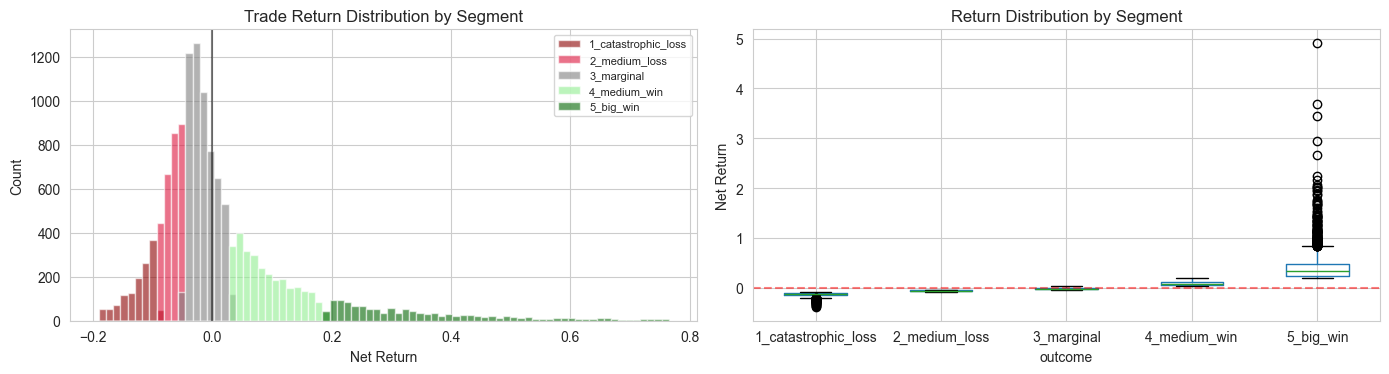


📊 Investigation cohorts:
   Losers:        4,289 trades (avg return: -8.852%)
   Winners:       4,289 trades (avg return: 20.372%)
   Catastrophic:  1,430 trades (avg return: -13.354%)


In [5]:
# === Visualize return distribution ===
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram with segments shaded
ax = axes[0]
bins = np.linspace(training_df['net_return'].quantile(0.01),
                   training_df['net_return'].quantile(0.99), 80)
colors = {'1_catastrophic_loss': '#8B0000',
          '2_medium_loss':       '#DC143C',
          '3_marginal':          '#808080',
          '4_medium_win':        '#90EE90',
          '5_big_win':           '#006400'}
for outcome, color in colors.items():
    subset = training_df[training_df['outcome']==outcome]['net_return']
    ax.hist(subset, bins=bins, alpha=0.6, label=outcome, color=color)
ax.axvline(0, color='black', linestyle='-', alpha=0.5)
ax.set_xlabel('Net Return')
ax.set_ylabel('Count')
ax.set_title('Trade Return Distribution by Segment')
ax.legend(fontsize=8)

# Box plot
ax = axes[1]
training_df.boxplot(column='net_return', by='outcome', ax=ax,
                    showfliers=True, patch_artist=False)
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_title('Return Distribution by Segment')
ax.set_ylabel('Net Return')
plt.suptitle('')
plt.tight_layout()
plt.show()

# === Define loser groups for analysis ===
# We'll focus on catastrophic + medium losers vs big + medium wins
# (skipping marginal noise in the middle)
losers  = training_df[training_df['outcome'].isin(['1_catastrophic_loss', '2_medium_loss'])].copy()
winners = training_df[training_df['outcome'].isin(['4_medium_win', '5_big_win'])].copy()
catastrophic = training_df[training_df['outcome']=='1_catastrophic_loss'].copy()

print(f"\n📊 Investigation cohorts:")
print(f"   Losers:        {len(losers):,} trades (avg return: {losers['net_return'].mean():.3%})")
print(f"   Winners:       {len(winners):,} trades (avg return: {winners['net_return'].mean():.3%})")
print(f"   Catastrophic:  {len(catastrophic):,} trades (avg return: {catastrophic['net_return'].mean():.3%})")

# 3. Univariate Feature Analysis

Compare the **distribution of each feature** between losers and winners. Features with significantly different distributions are predictive — those are exactly the features that should be in your model.


In [6]:
# === Identify numeric feature columns ===
exclude_cols = {
    'symbol', 'entry_date', 'exit_date', 'date', 'col', 'entry_idx', 'exit_idx',
    'return', 'net_return', 'Y', 'outcome', 'metadata', 'type',
    'entry_price', 'exit_price', 'size', 'pnl', 'status', 'index',
    'open', 'high', 'low', 'close', 'volume',
    'direction', 'parent_id', 'id',
}
feature_cols = [
    c for c in training_df.columns
    if c not in exclude_cols
    and pd.api.types.is_numeric_dtype(training_df[c])
    and training_df[c].nunique() > 5     # skip near-constants
]
print(f"Analyzing {len(feature_cols)} numeric features")

Analyzing 29 numeric features


In [7]:
# === Compute discriminative power per feature ===
def feature_discrimination(df_loss: pd.DataFrame, df_win: pd.DataFrame, 
                            features: list) -> pd.DataFrame:
    """
    For each feature, compute statistical separation between losers and winners.
    
    Returns DataFrame with:
    - cohen_d:    standardized mean difference (effect size)
    - ks_stat:    Kolmogorov-Smirnov statistic (distribution shape difference)
    - ks_pvalue:  KS test p-value
    - mwu_pvalue: Mann-Whitney U p-value (rank-based, robust)
    - winner_mean, loser_mean
    """
    rows = []
    for f in features:
        a = df_loss[f].dropna().values
        b = df_win[f].dropna().values
        if len(a) < 10 or len(b) < 10:
            continue
        
        # Cohen's d (standardized effect size)
        pooled_std = np.sqrt((np.var(a, ddof=1) + np.var(b, ddof=1)) / 2)
        cohen_d = (np.mean(b) - np.mean(a)) / (pooled_std + 1e-9)
        
        # KS test (different distributions?)
        ks_stat, ks_p = stats.ks_2samp(a, b)
        
        # Mann-Whitney U (different rank distributions?)
        try:
            mwu_stat, mwu_p = stats.mannwhitneyu(a, b, alternative='two-sided')
        except ValueError:
            mwu_p = 1.0
        
        rows.append({
            'feature':     f,
            'loser_mean':  np.mean(a),
            'winner_mean': np.mean(b),
            'cohen_d':     cohen_d,
            'abs_cohen_d': abs(cohen_d),
            'ks_stat':     ks_stat,
            'ks_pvalue':   ks_p,
            'mwu_pvalue':  mwu_p,
        })
    
    return pd.DataFrame(rows).sort_values('abs_cohen_d', ascending=False)

discrim_df = feature_discrimination(losers, winners, feature_cols)
print("Top 15 most discriminative features (winners vs losers):")
print(discrim_df.head(15).to_string(index=False))

Top 15 most discriminative features (winners vs losers):
               feature  loser_mean  winner_mean   cohen_d  abs_cohen_d  ks_stat    ks_pvalue   mwu_pvalue
           msr_rank_10    0.705058     0.663630 -0.175070     0.175070 0.095360 2.181476e-17 5.089141e-19
                mrs_10    2.754458     2.155602 -0.147030     0.147030 0.065750 1.752821e-08 7.338731e-11
                 rs_10    1.505430     0.692905 -0.139066     0.139066 0.064817 2.957002e-08 1.975199e-08
                mrs_20    0.978586     0.211123 -0.132884     0.132884 0.060620 2.835353e-07 2.750681e-08
           kf_distance    0.014309     0.008839 -0.111672     0.111672 0.056657 2.086202e-06 1.907349e-07
       ema_20_distance    0.014325     0.008861 -0.111652     0.111652 0.056657 2.086202e-06 1.919123e-07
volume_threshold_ma_20   -0.488820    -0.210086  0.109561     0.109561 0.026113 1.073469e-01 7.467367e-01
       ema_50_distance    0.007030    -0.003452 -0.106891     0.106891 0.052926 1.206396e-05 6.

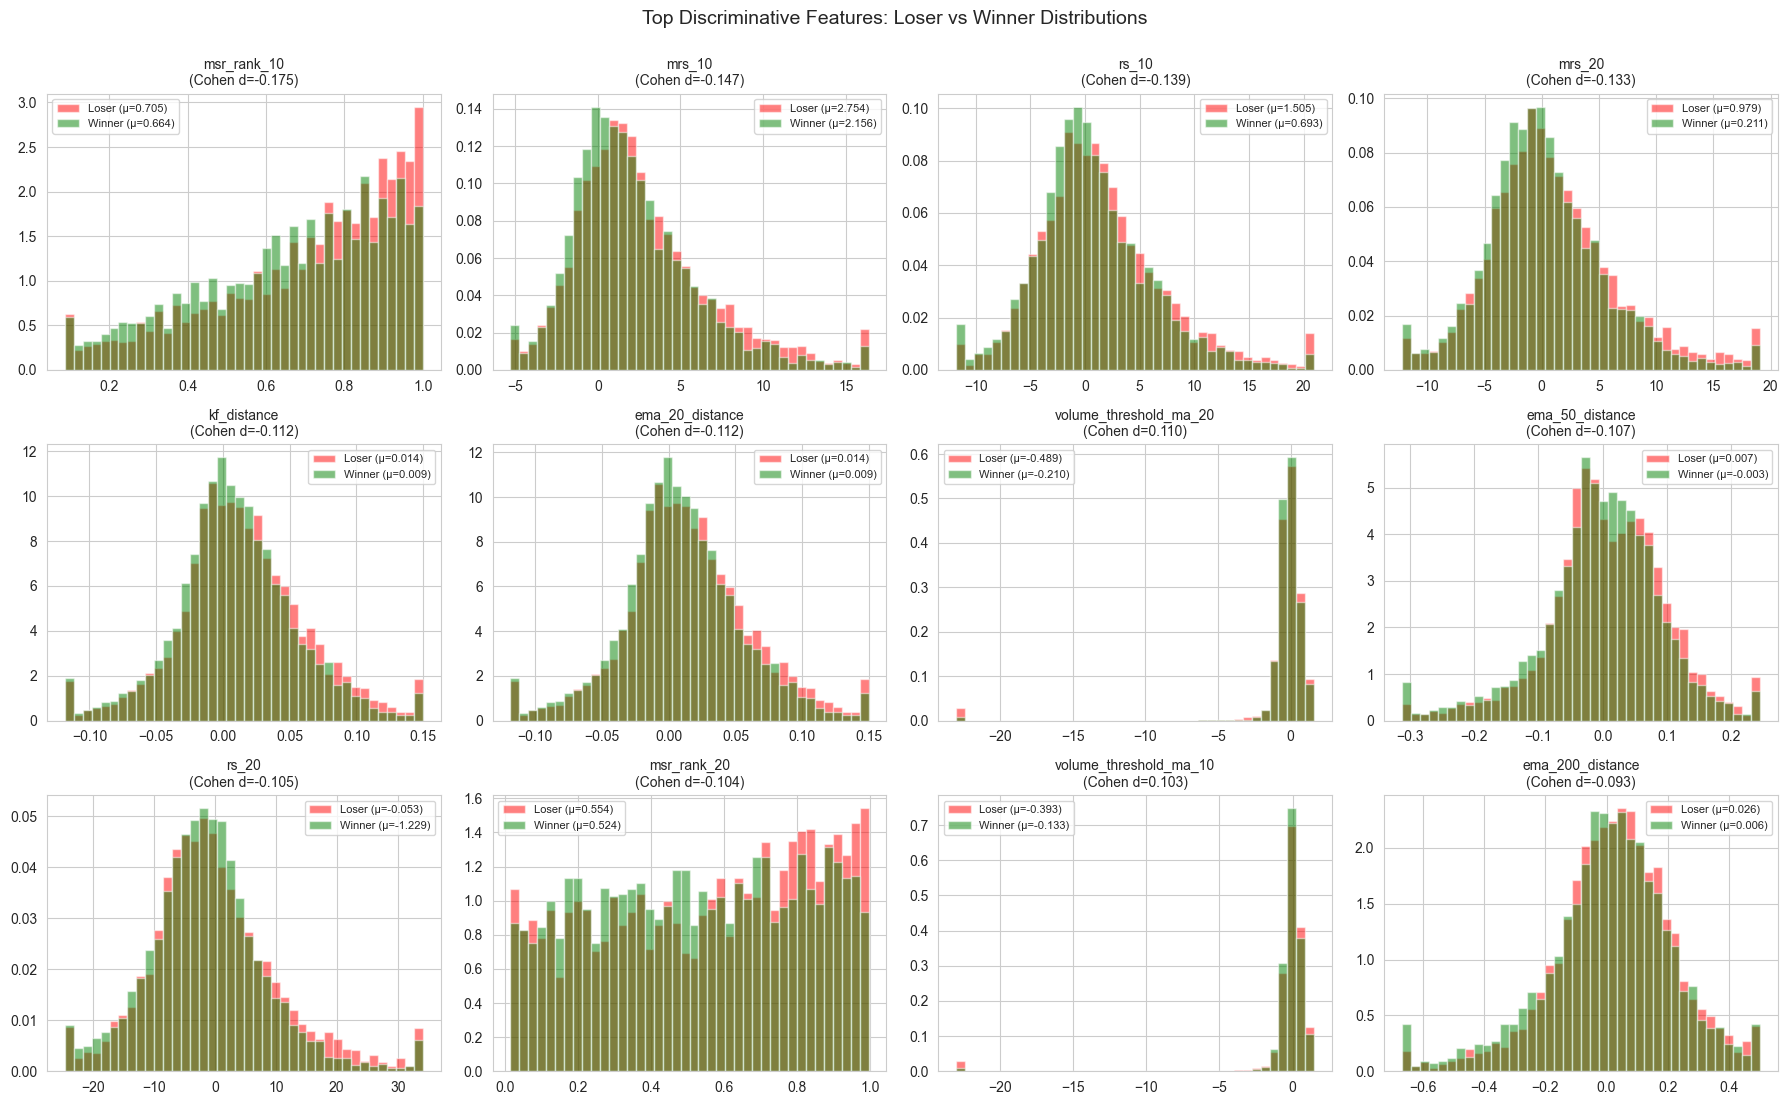

In [8]:
# === Visualize top discriminative features ===
top_features = discrim_df.head(12)['feature'].tolist()

fig, axes = plt.subplots(3, 4, figsize=(18, 11))
for ax, feat in zip(axes.flat, top_features):
    loser_vals  = losers[feat].dropna()
    winner_vals = winners[feat].dropna()
    
    # Trim outliers for visualization
    p1 = min(loser_vals.quantile(0.01), winner_vals.quantile(0.01))
    p99 = max(loser_vals.quantile(0.99), winner_vals.quantile(0.99))
    
    ax.hist(loser_vals.clip(p1, p99),  bins=40, alpha=0.5, 
            label=f'Loser (μ={loser_vals.mean():.3f})', color='red',     density=True)
    ax.hist(winner_vals.clip(p1, p99), bins=40, alpha=0.5, 
            label=f'Winner (μ={winner_vals.mean():.3f})', color='green', density=True)
    
    d = discrim_df.set_index('feature').loc[feat, 'cohen_d']
    ax.set_title(f'{feat}\n(Cohen d={d:.3f})', fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel('')

plt.suptitle('Top Discriminative Features: Loser vs Winner Distributions', 
             fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

In [9]:
# === Effect size interpretation ===
print("""
💡 Cohen's d Interpretation Guide:
   |d| < 0.2  → trivial difference (feature unlikely to help)
   |d| 0.2-0.5 → small effect (modest signal)
   |d| 0.5-0.8 → medium effect (real signal worth modeling)
   |d| > 0.8  → large effect (strongly discriminative)

   Negative d → loser mean > winner mean
   Positive d → winner mean > loser mean
""")

# Categorize by effect size
strong = discrim_df[discrim_df['abs_cohen_d'] > 0.5]
medium = discrim_df[(discrim_df['abs_cohen_d'] > 0.2) & (discrim_df['abs_cohen_d'] <= 0.5)]
weak   = discrim_df[discrim_df['abs_cohen_d'] <= 0.2]

print(f"📊 Effect size summary:")
print(f"   Strong (|d| > 0.5):   {len(strong):3d} features")
print(f"   Medium (|d| 0.2-0.5): {len(medium):3d} features")
print(f"   Weak   (|d| < 0.2):   {len(weak):3d} features (consider dropping)\n")

if len(strong) > 0:
    print("Strong discriminators worth keeping:")
    print(strong[['feature', 'loser_mean', 'winner_mean', 'cohen_d']].to_string(index=False))


💡 Cohen's d Interpretation Guide:
   |d| < 0.2  → trivial difference (feature unlikely to help)
   |d| 0.2-0.5 → small effect (modest signal)
   |d| 0.5-0.8 → medium effect (real signal worth modeling)
   |d| > 0.8  → large effect (strongly discriminative)

   Negative d → loser mean > winner mean
   Positive d → winner mean > loser mean

📊 Effect size summary:
   Strong (|d| > 0.5):     0 features
   Medium (|d| 0.2-0.5):   0 features
   Weak   (|d| < 0.2):    29 features (consider dropping)



# 4. Catastrophic Loss Deep Dive

The biggest losers drag down your Sharpe the most. Even filtering 50% of these would dramatically improve risk-adjusted returns. Let's understand what they have in common.


In [10]:
# === What's special about catastrophic losers? ===
catastrophic_vs_others = feature_discrimination(
    catastrophic,
    training_df[training_df['outcome'] != '1_catastrophic_loss'],
    feature_cols,
)

print("🚨 Top 15 features distinguishing CATASTROPHIC losers from everything else:")
print(catastrophic_vs_others.head(15).to_string(index=False))

🚨 Top 15 features distinguishing CATASTROPHIC losers from everything else:
               feature  loser_mean  winner_mean   cohen_d  abs_cohen_d  ks_stat     ks_pvalue    mwu_pvalue
             yz_vol_10    0.572776     0.395639 -0.748235     0.748235 0.371516 6.388741e-160 2.704649e-189
             yz_vol_20    0.564105     0.400181 -0.743572     0.743572 0.365673 8.878240e-155 5.047920e-182
                mrs_10    3.918744     1.789674 -0.490309     0.490309 0.210643  1.400949e-50  2.917288e-60
           msr_rank_10    0.743414     0.652209 -0.385461     0.385461 0.188177  2.242252e-40  1.195149e-53
                 rs_10    2.413792     0.618004 -0.280022     0.280022 0.134720  7.834480e-21  4.166476e-16
       ema_10_distance    0.025480     0.016436 -0.277413     0.277413 0.162616  3.321479e-30  1.868311e-19
 vwap_distance_highest   -0.116524    -0.073922  0.266977     0.266977 0.136582  2.108925e-21  5.789350e-14
                mrs_20    1.791958     0.102489 -0.265573    

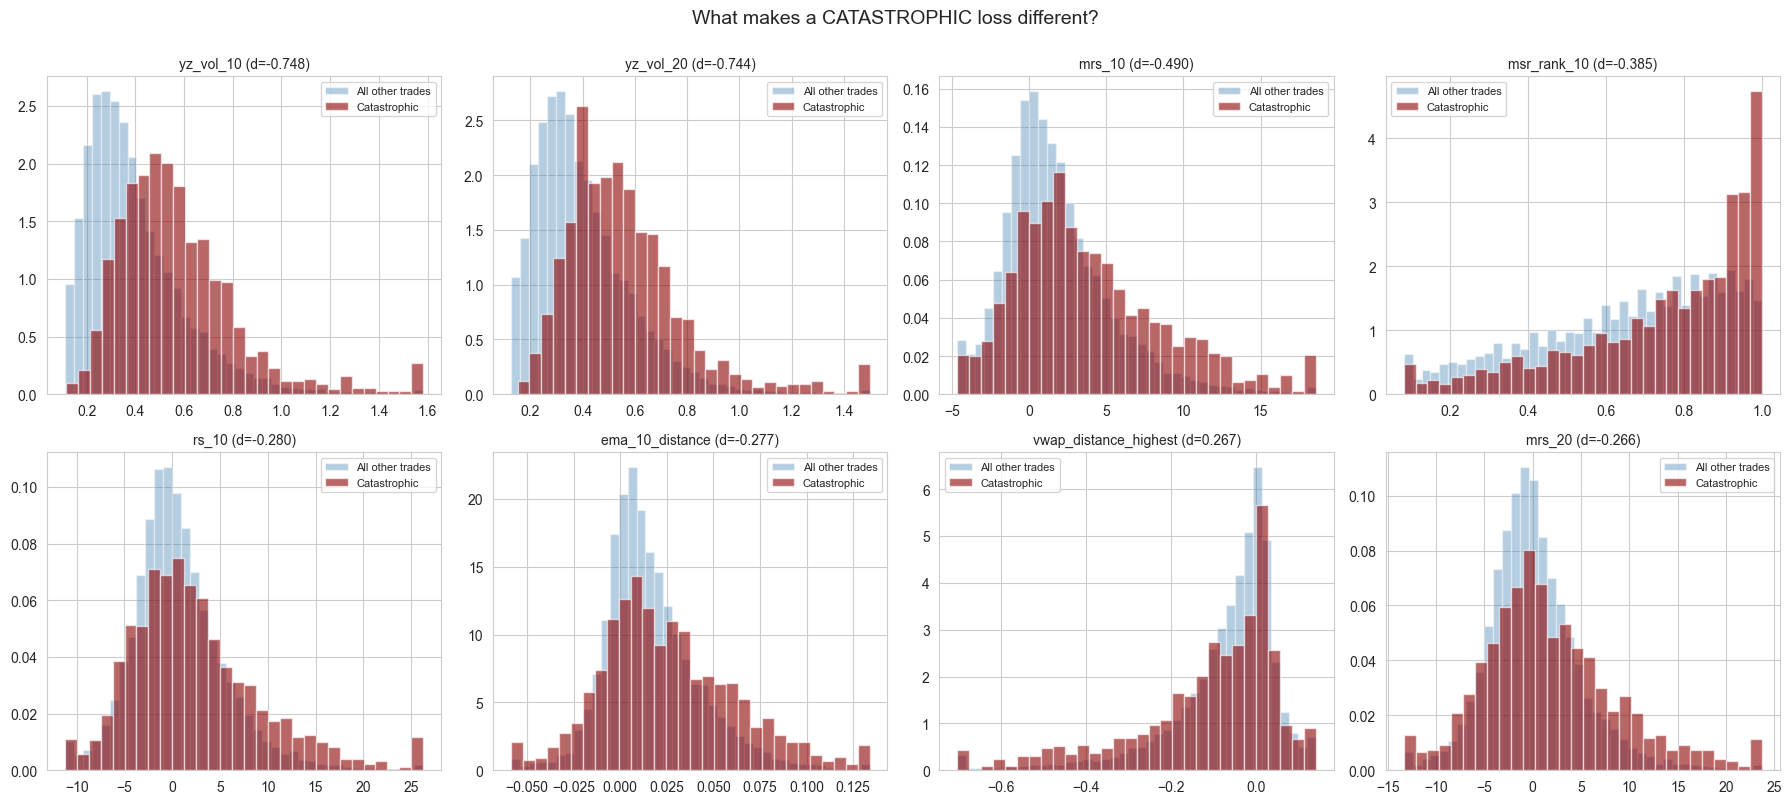

In [11]:
# === Visualize: catastrophic vs rest ===
top_cat_feats = catastrophic_vs_others.head(8)['feature'].tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, feat in zip(axes.flat, top_cat_feats):
    cat_vals    = catastrophic[feat].dropna()
    others_vals = training_df[training_df['outcome'] != '1_catastrophic_loss'][feat].dropna()
    
    p1  = min(cat_vals.quantile(0.01), others_vals.quantile(0.01))
    p99 = max(cat_vals.quantile(0.99), others_vals.quantile(0.99))
    
    ax.hist(others_vals.clip(p1, p99), bins=40, alpha=0.4, 
            label='All other trades', color='steelblue', density=True)
    ax.hist(cat_vals.clip(p1, p99),    bins=30, alpha=0.6, 
            label='Catastrophic',     color='darkred',   density=True)
    
    d = catastrophic_vs_others.set_index('feature').loc[feat, 'cohen_d']
    ax.set_title(f'{feat} (d={d:.3f})', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('What makes a CATASTROPHIC loss different?', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

# 5. Time & Regime Analysis

Do losers cluster in specific time periods? This often reveals **market regime** dependencies that your strategy doesn't capture.


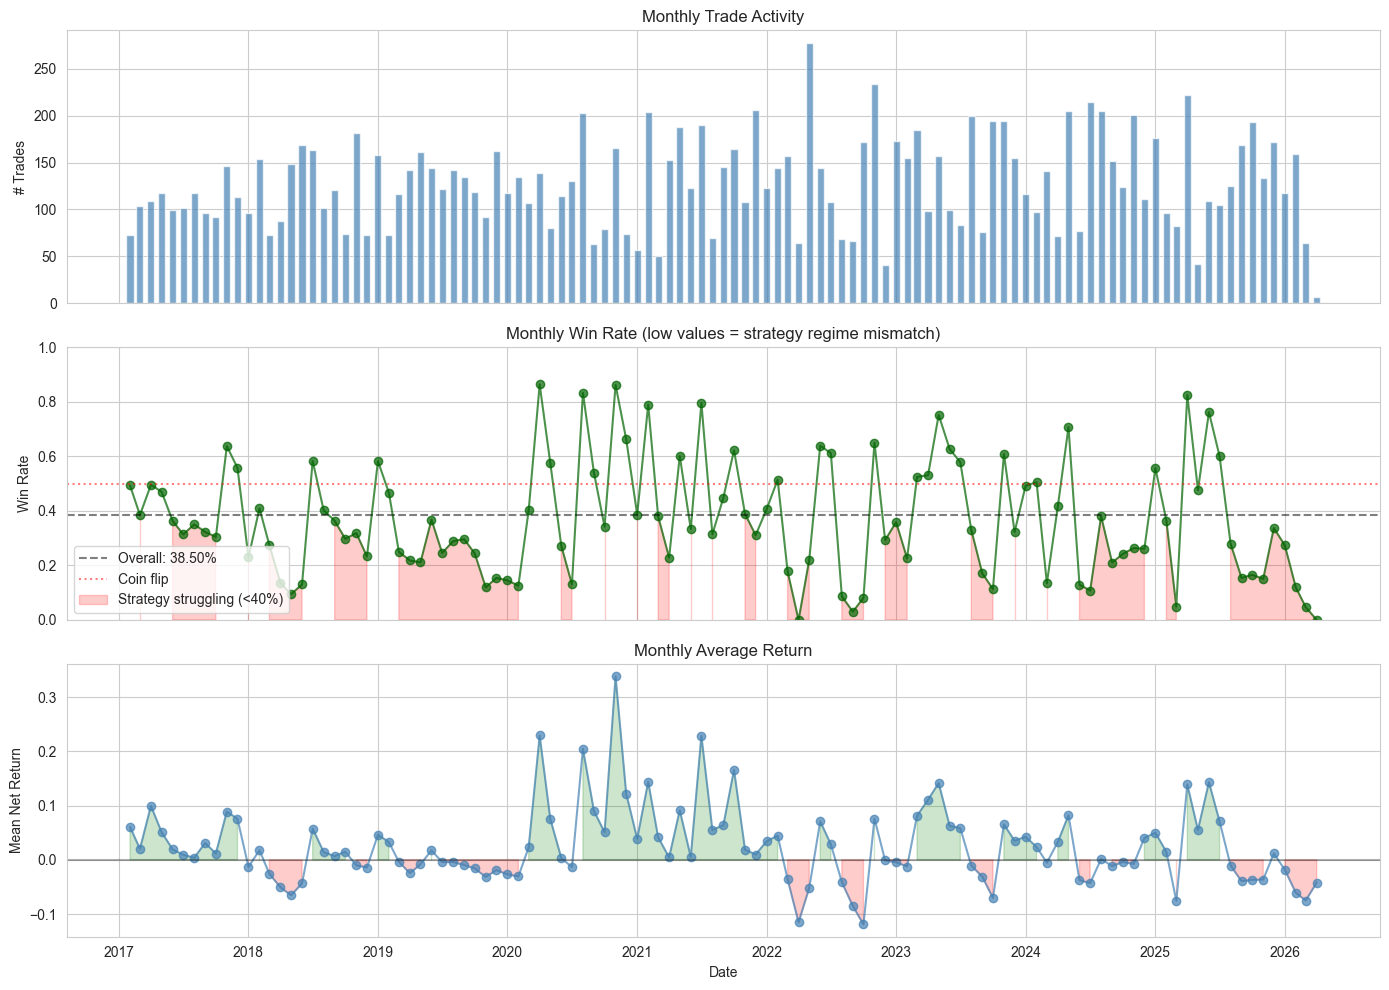

📉 Top 10 WORST months (look for regime patterns here):
year_month  n_trades  win_rate  avg_return  median_return
2022-10-01       172  0.081395   -0.118795      -0.133483
2022-04-01        64  0.000000   -0.115108      -0.106785
2022-09-01        66  0.030303   -0.085198      -0.079879
2025-03-01        82  0.048780   -0.075672      -0.069765
2026-03-01        64  0.046875   -0.074932      -0.077574
2023-10-01       194  0.113402   -0.070101      -0.076318
2018-05-01       148  0.094595   -0.065336      -0.067352
2026-02-01       159  0.119497   -0.060750      -0.067815
2022-05-01       277  0.220217   -0.051927      -0.055709
2018-04-01        88  0.136364   -0.050435      -0.062093


In [12]:
# === Win rate over time ===
training_df['year_month'] = training_df['entry_date'].dt.to_period('M')

monthly_stats = training_df.groupby('year_month').agg(
    n_trades=('Y', 'count'),
    win_rate=('Y', 'mean'),
    avg_return=('net_return', 'mean'),
    median_return=('net_return', 'median'),
).reset_index()
monthly_stats['year_month'] = monthly_stats['year_month'].dt.to_timestamp()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Plot 1: trade count
axes[0].bar(monthly_stats['year_month'], monthly_stats['n_trades'], 
            width=20, color='steelblue', alpha=0.7)
axes[0].set_ylabel('# Trades')
axes[0].set_title('Monthly Trade Activity')

# Plot 2: win rate
axes[1].plot(monthly_stats['year_month'], monthly_stats['win_rate'], 
             marker='o', color='darkgreen', alpha=0.7)
axes[1].axhline(training_df['Y'].mean(), color='black', linestyle='--', 
                alpha=0.5, label=f"Overall: {training_df['Y'].mean():.2%}")
axes[1].axhline(0.5, color='red', linestyle=':', alpha=0.5, label='Coin flip')
axes[1].fill_between(monthly_stats['year_month'], 0, monthly_stats['win_rate'], 
                     where=(monthly_stats['win_rate'] < 0.4), color='red', alpha=0.2,
                     label='Strategy struggling (<40%)')
axes[1].set_ylabel('Win Rate')
axes[1].set_ylim(0, 1)
axes[1].legend(loc='lower left')
axes[1].set_title('Monthly Win Rate (low values = strategy regime mismatch)')

# Plot 3: mean return
axes[2].plot(monthly_stats['year_month'], monthly_stats['avg_return'], 
             marker='o', color='steelblue', alpha=0.7)
axes[2].axhline(0, color='black', linestyle='-', alpha=0.3)
axes[2].fill_between(monthly_stats['year_month'], 0, monthly_stats['avg_return'],
                     where=(monthly_stats['avg_return'] < 0), color='red', alpha=0.2)
axes[2].fill_between(monthly_stats['year_month'], 0, monthly_stats['avg_return'],
                     where=(monthly_stats['avg_return'] > 0), color='green', alpha=0.2)
axes[2].set_ylabel('Mean Net Return')
axes[2].set_xlabel('Date')
axes[2].set_title('Monthly Average Return')

plt.tight_layout()
plt.show()

# Identify worst months
worst_months = monthly_stats.nsmallest(10, 'avg_return')
print("📉 Top 10 WORST months (look for regime patterns here):")
print(worst_months.to_string(index=False))

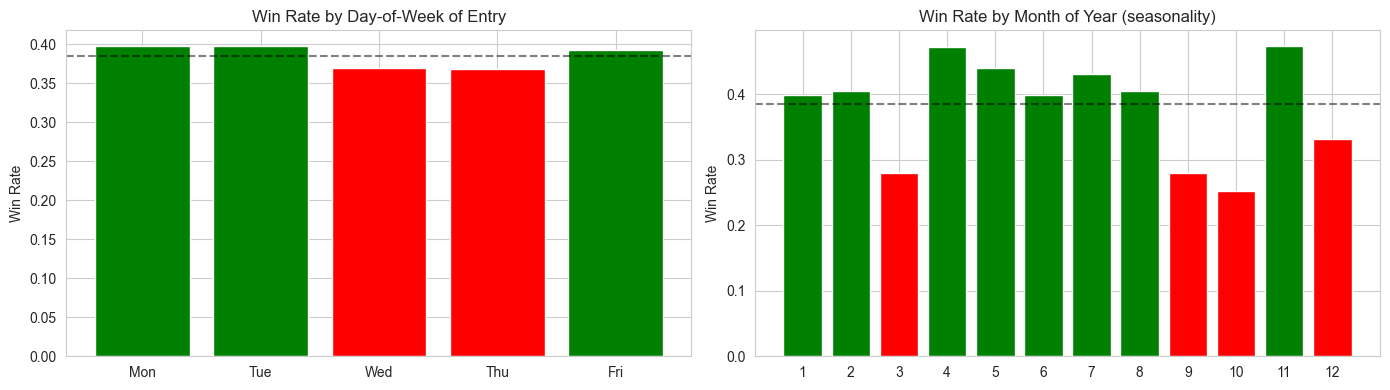

Day-of-week effect — χ² test p-value: 0.0274
   ✅ Significant: day-of-week matters for trade outcomes


In [13]:
# === Day-of-week and month-of-year patterns ===
training_df['dow']   = training_df['entry_date'].dt.dayofweek
training_df['month'] = training_df['entry_date'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Day of week
dow_stats = training_df.groupby('dow').agg(
    win_rate=('Y', 'mean'),
    n_trades=('Y', 'count'),
).reset_index()
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
axes[0].bar(dow_stats['dow'][:5], dow_stats['win_rate'][:5], 
            color=['red' if w < training_df['Y'].mean() else 'green' 
                   for w in dow_stats['win_rate'][:5]])
axes[0].axhline(training_df['Y'].mean(), color='black', linestyle='--', alpha=0.5)
axes[0].set_xticks(range(5))
axes[0].set_xticklabels(dow_labels)
axes[0].set_ylabel('Win Rate')
axes[0].set_title('Win Rate by Day-of-Week of Entry')

# Month of year
month_stats = training_df.groupby('month').agg(
    win_rate=('Y', 'mean'),
    n_trades=('Y', 'count'),
).reset_index()
axes[1].bar(month_stats['month'], month_stats['win_rate'],
            color=['red' if w < training_df['Y'].mean() else 'green' 
                   for w in month_stats['win_rate']])
axes[1].axhline(training_df['Y'].mean(), color='black', linestyle='--', alpha=0.5)
axes[1].set_xticks(range(1, 13))
axes[1].set_ylabel('Win Rate')
axes[1].set_title('Win Rate by Month of Year (seasonality)')

plt.tight_layout()
plt.show()

# Statistical significance of weekday effect
from scipy.stats import chi2_contingency
ct = pd.crosstab(training_df['dow'], training_df['Y'])
chi2, p, _, _ = chi2_contingency(ct)
print(f"Day-of-week effect — χ² test p-value: {p:.4f}")
if p < 0.05:
    print("   ✅ Significant: day-of-week matters for trade outcomes")
else:
    print("   ❌ Not significant: day-of-week doesn't matter")

# 6. Symbol-Level Hotspots

Some symbols may consistently produce bad trades for your strategy. This often reveals strategy-stock mismatches (e.g., your breakout strategy doesn't work on highly mean-reverting stocks).


In [14]:
# === Per-symbol performance ===
symbol_stats = training_df.groupby('symbol').agg(
    n_trades=('Y', 'count'),
    win_rate=('Y', 'mean'),
    avg_return=('net_return', 'mean'),
    median_return=('net_return', 'median'),
    sum_return=('net_return', 'sum'),
).reset_index()

# Filter symbols with enough sample size
symbol_stats = symbol_stats[symbol_stats['n_trades'] >= 10]
symbol_stats = symbol_stats.sort_values('avg_return')

# Top 10 worst symbols
print("🚨 Worst 10 symbols (avg return) with ≥10 trades:")
print(symbol_stats.head(10).to_string(index=False))
print("\n✨ Best 10 symbols:")
print(symbol_stats.tail(10).to_string(index=False))

🚨 Worst 10 symbols (avg return) with ≥10 trades:
symbol  n_trades  win_rate  avg_return  median_return  sum_return
   DVM        28  0.142857   -0.036907      -0.050304   -1.033403
   HHV        69  0.275362   -0.028647      -0.037532   -1.976672
   PVP        92  0.260870   -0.017771      -0.038406   -1.634976
   QTP        74  0.310811   -0.015726      -0.025663   -1.163696
   SAB        92  0.217391   -0.009155      -0.021893   -0.842242
   NHH        80  0.275000   -0.007745      -0.030458   -0.619610
   PLC        72  0.305556   -0.005978      -0.035293   -0.430445
   MIG        76  0.368421   -0.005561      -0.020340   -0.422637
   VRE        79  0.316456   -0.004696      -0.029912   -0.370960
   KHG        39  0.256410   -0.003919      -0.035414   -0.152832

✨ Best 10 symbols:
symbol  n_trades  win_rate  avg_return  median_return  sum_return
   NHA        73  0.369863    0.076820      -0.025422    5.607863
   DIG        73  0.424658    0.078169      -0.026901    5.706345
   MCH 

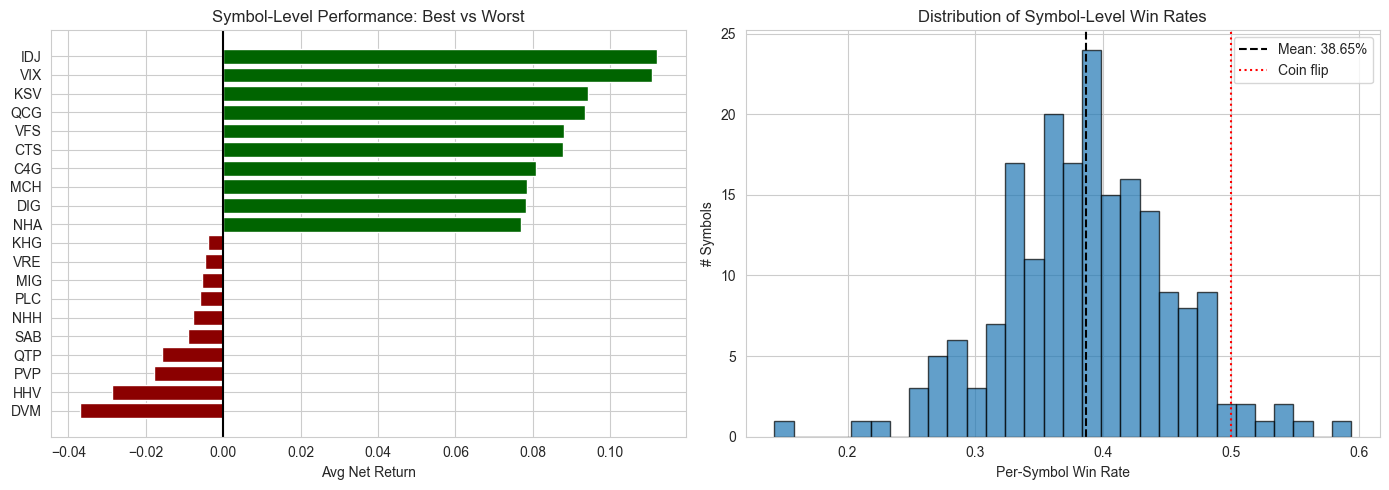


💀 Chronic loser symbols (win rate < 35%, ≥20 trades):
symbol  n_trades  win_rate  avg_return
   DVM        28  0.142857   -0.036907
   HHV        69  0.275362   -0.028647
   PVP        92  0.260870   -0.017771
   QTP        74  0.310811   -0.015726
   SAB        92  0.217391   -0.009155
   NHH        80  0.275000   -0.007745
   PLC        72  0.305556   -0.005978
   VRE        79  0.316456   -0.004696
   KHG        39  0.256410   -0.003919
   POW        75  0.333333   -0.003481
   HDB        82  0.341463   -0.002617
   VPI        70  0.285714   -0.000099
   NT2        78  0.346154    0.000598
   KOS        63  0.285714    0.002057
   VNM        90  0.311111    0.002641
   HPX        60  0.333333    0.003383
   VHM        77  0.272727    0.003771
   BMP        81  0.345679    0.004807
   PLX        84  0.333333    0.005417
   REE        99  0.323232    0.005862
   VCG        86  0.302326    0.006056
   LAS        75  0.280000    0.006523
   HNG        75  0.253333    0.006696
   VC7   

In [15]:
# === Visualize symbol distribution of returns ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: best/worst symbols
top10_worst = symbol_stats.head(10)
top10_best  = symbol_stats.tail(10)
combined = pd.concat([top10_worst, top10_best])
colors = ['darkred']*10 + ['darkgreen']*10
axes[0].barh(combined['symbol'], combined['avg_return'], color=colors)
axes[0].axvline(0, color='black')
axes[0].set_xlabel('Avg Net Return')
axes[0].set_title('Symbol-Level Performance: Best vs Worst')

# Distribution of symbol-level win rates
axes[1].hist(symbol_stats['win_rate'], bins=30, alpha=0.7, edgecolor='black')
axes[1].axvline(symbol_stats['win_rate'].mean(), color='black', 
                linestyle='--', label=f"Mean: {symbol_stats['win_rate'].mean():.2%}")
axes[1].axvline(0.5, color='red', linestyle=':', label='Coin flip')
axes[1].set_xlabel('Per-Symbol Win Rate')
axes[1].set_ylabel('# Symbols')
axes[1].set_title('Distribution of Symbol-Level Win Rates')
axes[1].legend()

plt.tight_layout()
plt.show()

# Identify "consistently bad" symbols (low win rate AND many trades)
chronic_losers = symbol_stats[
    (symbol_stats['win_rate'] < 0.35) & (symbol_stats['n_trades'] >= 20)
]
print(f"\n💀 Chronic loser symbols (win rate < 35%, ≥20 trades):")
print(chronic_losers[['symbol', 'n_trades', 'win_rate', 'avg_return']].to_string(index=False))

# 7. Path Analysis: How Do Losers Unfold?

For each trade, look at **Maximum Favorable Excursion** (MFE — best unrealized P&L) and **Maximum Adverse Excursion** (MAE — worst unrealized P&L). This reveals whether losers were ever profitable, and how much profit you give back on average.


In [17]:
## Load datasource from deltalake and save it to local h5 file
REMOTE_HOST = "http://192.168.1.30:9000"
# REMOTE_HOST = "https://minio.phuchuynh.xyz"

from deltalake import DeltaTable
def load_stock_data() -> pd.DataFrame:
    """Load stock data from delta lake, ensuring index uniqueness to avoid unstack ValueError"""
    try:
        from deltalake import DeltaTable
        storage_options = {
            "AWS_ACCESS_KEY_ID": "CzOwnLkEDXQy951AOqes",
            "AWS_SECRET_ACCESS_KEY": "fdRe91TOtqTl0icUkZLsUnWvZa90aZ5qG5rVEf7S",
            "AWS_ENDPOINT_URL": REMOTE_HOST,
            "AWS_ALLOW_HTTP": "true",
            "AWS_EC2_METADATA_DISABLED": "true",
            "AWS_REGION": 'us-east-1',
            "aws_conditional_put": "etag",
        }        
        dt = DeltaTable("s3://delta-table-storage/stocks", storage_options=storage_options)

        # Get data for last 2 years
        # Load watchlist symbols from CSV
        watchlist_path = "../backend/models/watchlist.csv"
        watchlist_df = pd.read_csv(watchlist_path)
        watchlist_symbols = watchlist_df.iloc[:, 0].values

        now = pd.Timestamp.now()
        start_date = now - pd.DateOffset(years=10)
        # Load all, then filter
        df = dt.to_pandas(
            filters=[("date", ">=", start_date), ("symbol", "in", watchlist_symbols)], 
            columns=["symbol", "date", "close", "open", "high", "low", "volume"]
        )
        
        # Remove duplicate (date, symbol) rows by keeping the last occurrence
        df = df.drop_duplicates(subset=["date", "symbol"], keep="last")
        # Convert to the same format as H5 store
        df = df.set_index(["date", "symbol"])
        stocks = df.unstack(level=1).bfill().ffill()
        
        print("Successfully loaded data from delta lake")
        return stocks
        
    except Exception as e:
        print(f"Error loading from delta lake: {e}")
        raise

import os
import pandas as pd

local_file = "stocks_data_latest.h5"
store_key = "stocks"

if os.path.exists(local_file):
    print(f"Loading stock data from local HDF5 file: {local_file}")
    with pd.HDFStore(local_file, mode="r") as store:
        df = store[store_key]
else:
    print("Local HDF5 file not found, loading stock data from Delta Lake...")
    df = load_stock_data()
    with pd.HDFStore(local_file, mode="w") as store:
        store.put(store_key, df)
    print(f"Stock data saved to {local_file}")

# Filter df to keep only columns for symbols in the watchlist (once)
watchlist_path = "../backend/models/watchlist.csv"
watchlist_df = pd.read_csv(watchlist_path)
watchlist_symbols = watchlist_df.iloc[:, 0].values
stocks = df.loc[:, df.columns.get_level_values('symbol').isin(watchlist_symbols)]
stocks


Loading stock data from local HDF5 file: stocks_data_latest.h5


close                                                               \
symbol       AAA    ABB    ACB    ACV   ADS    AGG    AGR    ANV    APH   ASM   
date                                                                            
2016-04-20  9.23   7.48   2.83  20.63  3.70  15.28   2.50   1.16  30.17  7.57   
2016-04-21  9.33   7.48   2.83  20.63  3.70  15.28   2.59   1.21  30.17  7.61   
2016-04-22  9.33   7.48   2.91  20.63  3.70  15.28   2.50   1.21  30.17  7.61   
2016-04-25  9.18   7.48   2.88  20.63  3.70  15.28   2.50   1.16  30.17  7.61   
2016-04-26  9.28   7.48   2.88  20.63  3.70  15.28   2.50   1.18  30.17  7.44   
...          ...    ...    ...    ...   ...    ...    ...    ...    ...   ...   
2026-04-13  7.01  14.60  23.75  46.30  8.64  13.00  14.95  24.35   5.56  5.86   
2026-04-14  7.10  14.60  24.00  46.40  9.07  12.90  15.05  24.90   5.58  5.94   
2026-04-15  7.12  14.50  23.80  46.70  9.11  12.95  14.95  24.45   5.62  5.89   
2026-04-16  7.04  14.60  23.65  46.30  9.12  12.80  14.90  24.75   5.57  5.80   
2026-04-17  7.03  14.60  23.75  45.90  9.09  12.90  14.85  25.00   5.58  5.77   

            ...       volume                                              \
symbol      ...      VNINDEX        VNM        VOS         VPB       VPG   
date        ...                                                            
2016-04-20  ...  108722464.0  1698460.0   154430.0  58299312.0    5000.0   
2016-04-21  ...  100005664.0   748780.0    82430.0  58299312.0    5000.0   
2016-04-22  ...  129717344.0   938560.0    94700.0  58299312.0    5000.0   
2016-04-25  ...  130331664.0   886480.0    58550.0  58299312.0    5000.0   
2016-04-26  ...  132638552.0   604360.0    87030.0  58299312.0    5000.0   
...         ...          ...        ...        ...         ...       ...   
2026-04-13  ...  767253440.0  3418300.0   876100.0  13557000.0  287600.0   
2026-04-14  ...  774260224.0  4247700.0   811900.0  14453500.0  316900.0   
2026-04-15  ...  804903616.0  4403200.0   935100.0  12229700.0  621100.0   
2026-04-16  ...  973731840.0  2272100.0  1491800.0  15412800.0  177000.0   
2026-04-17  ...  707285376.0  3115500.0  1314500.0  25668400.0  217700.0   

                                                                   
symbol            VPI         VRE        VSC       VTP        YEG  
date                                                               
2016-04-20     5000.0       800.0   156340.0     300.0     6100.0  
2016-04-21     5000.0       800.0    26330.0     300.0     6100.0  
2016-04-22     5000.0       800.0    67380.0     300.0     6100.0  
2016-04-25     5000.0       800.0    75940.0     300.0     6100.0  
2016-04-26     5000.0       800.0    36720.0     300.0     6100.0  
...               ...         ...        ...       ...        ...  
2026-04-13   738300.0   3915100.0  5244900.0  526500.0  2288200.0  
2026-04-14   833300.0   3851100.0  7001200.0  741600.0  1162000.0  
2026-04-15   633400.0  14406500.0  6993100.0  394500.0  1292300.0  
2026-04-16   635000.0  16443400.0  9699500.0  584900.0  1057800.0  
2026-04-17  5037500.0   7239000.0  4773900.0  258100.0   549200.0  

[2500 rows x 985 columns]

In [18]:
# === Compute MFE/MAE for each trade ===
def compute_path_excursions(trades_df: pd.DataFrame, prices_panel: pd.DataFrame) -> pd.DataFrame:
    """
    For each trade, compute:
    - mfe: max favorable excursion (best possible exit %)
    - mae: max adverse excursion (worst drawdown during trade %)
    - efficiency: final return / mfe (how much of best move you captured)
    
    Args:
        trades_df: must have ['symbol', 'entry_date', 'exit_date', 'net_return']
        prices_panel: stocks panel (your `stocks` variable) with close prices
    """
    out = trades_df.copy()
    mfe_list, mae_list = [], []
    
    close = prices_panel['close']
    
    for _, trade in trades_df.iterrows():
        try:
            sym = trade['symbol']
            t0  = trade['entry_date']
            t1  = trade['exit_date']
            
            if sym not in close.columns:
                mfe_list.append(np.nan)
                mae_list.append(np.nan)
                continue
            
            path = close[sym].loc[t0:t1].dropna()
            if len(path) < 2:
                mfe_list.append(np.nan)
                mae_list.append(np.nan)
                continue
            
            entry_price = path.iloc[0]
            mfe = (path.max() / entry_price - 1)
            mae = (path.min() / entry_price - 1)
            mfe_list.append(mfe)
            mae_list.append(mae)
        except Exception:
            mfe_list.append(np.nan)
            mae_list.append(np.nan)
    
    out['mfe'] = mfe_list
    out['mae'] = mae_list
    out['efficiency'] = out['net_return'] / out['mfe'].replace(0, np.nan)
    out['holding_days'] = (out['exit_date'] - out['entry_date']).dt.days
    return out

# Compute (assumes `stocks` panel is in scope)
training_df = compute_path_excursions(training_df, stocks)

# losers / winners were sliced earlier — rebuild so they carry mfe, mae, efficiency
losers = training_df[training_df['outcome'].isin(['1_catastrophic_loss', '2_medium_loss'])].copy()
winners = training_df[training_df['outcome'].isin(['4_medium_win', '5_big_win'])].copy()

print("MFE/MAE statistics:")
print(training_df[['mfe', 'mae', 'efficiency', 'holding_days']].describe().round(3))

MFE/MAE statistics:
             mfe        mae  efficiency  holding_days
count  14296.000  14296.000   11534.000     14296.000
mean       0.127     -0.040      -1.629        32.701
std        0.232      0.042       6.144        34.274
min        0.000     -0.393    -124.810         1.000
25%        0.009     -0.058      -1.171        13.000
50%        0.055     -0.029      -0.000        24.000
75%        0.150     -0.008       0.463        43.000
max        7.563      0.000       0.929      1514.000


KeyError: 'mfe'

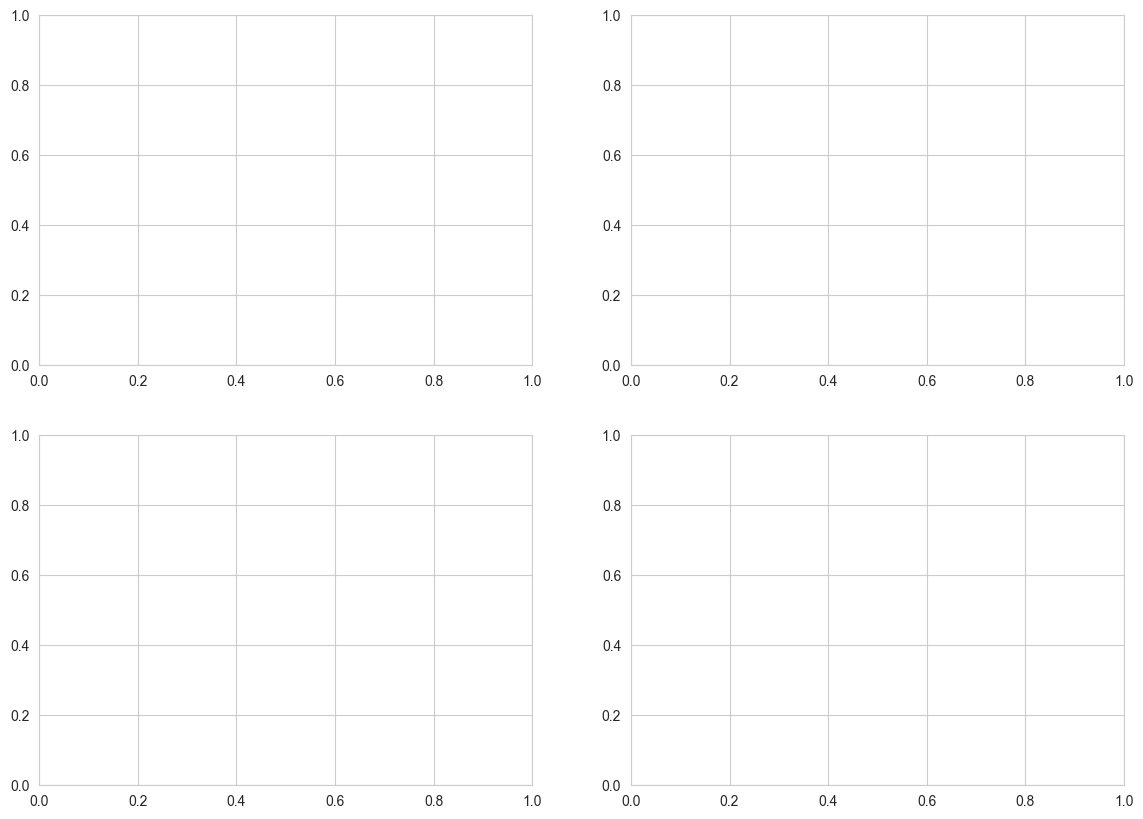

In [21]:
# === Visualize MFE/MAE patterns ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. MFE distribution: losers vs winners
ax = axes[0, 0]
ax.hist(losers['mfe'].dropna().clip(-0.05, 0.20),  bins=40, alpha=0.5, 
        label=f"Losers (μ={losers['mfe'].mean():.2%})",   color='red',   density=True)
ax.hist(winners['mfe'].dropna().clip(-0.05, 0.20), bins=40, alpha=0.5,
        label=f"Winners (μ={winners['mfe'].mean():.2%})", color='green', density=True)
ax.set_xlabel('Maximum Favorable Excursion')
ax.set_title('MFE: Did losers ever go positive?')
ax.legend()
ax.axvline(0, color='black', alpha=0.3)

# 2. MAE distribution
ax = axes[0, 1]
ax.hist(losers['mae'].dropna().clip(-0.20, 0.05),  bins=40, alpha=0.5,
        label=f"Losers (μ={losers['mae'].mean():.2%})",   color='red',   density=True)
ax.hist(winners['mae'].dropna().clip(-0.20, 0.05), bins=40, alpha=0.5,
        label=f"Winners (μ={winners['mae'].mean():.2%})", color='green', density=True)
ax.set_xlabel('Maximum Adverse Excursion')
ax.set_title('MAE: How much did winners drawdown first?')
ax.legend()
ax.axvline(0, color='black', alpha=0.3)

# 3. MFE vs MAE scatter
ax = axes[1, 0]
sample = training_df.dropna(subset=['mfe', 'mae']).sample(min(2000, len(training_df)))
sc = ax.scatter(sample['mae'], sample['mfe'], c=sample['Y'], 
                cmap='RdYlGn', alpha=0.4, s=10)
ax.axhline(0, color='black', alpha=0.3)
ax.axvline(0, color='black', alpha=0.3)
ax.set_xlabel('MAE (worst drawdown)')
ax.set_ylabel('MFE (best run-up)')
ax.set_title('Risk/Reward Profile per Trade (green=win)')
plt.colorbar(sc, ax=ax, label='Y (1=win)')

# 4. Holding period analysis
ax = axes[1, 1]
hold_bins = [0, 5, 10, 20, 40, 80, 200]
hold_labels = ['1-5d', '6-10d', '11-20d', '21-40d', '41-80d', '80d+']
training_df['hold_bin'] = pd.cut(training_df['holding_days'], bins=hold_bins, labels=hold_labels)
hold_stats = training_df.groupby('hold_bin', observed=True).agg(
    win_rate=('Y', 'mean'), 
    n=('Y', 'count'),
)
ax.bar(range(len(hold_stats)), hold_stats['win_rate'], 
       color=['red' if w < training_df['Y'].mean() else 'green' 
              for w in hold_stats['win_rate']])
ax.axhline(training_df['Y'].mean(), color='black', linestyle='--', alpha=0.5)
ax.set_xticks(range(len(hold_stats)))
ax.set_xticklabels(hold_stats.index, rotation=0)
ax.set_ylabel('Win Rate')
ax.set_title('Win Rate by Holding Period')
for i, n in enumerate(hold_stats['n']):
    ax.text(i, 0.05, f'n={n}', ha='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

# Key insights
print(f"\n💡 Key Path Insights:")
print(f"   • Losers' MFE ≥ 0:  {(losers['mfe'] > 0).mean():.1%} (% of losers that were once profitable)")
print(f"   • Winners' MAE ≤ -2%: {(winners['mae'] < -0.02).mean():.1%} (% of winners that drew down >2% first)")
print(f"   • Average efficiency: {training_df['efficiency'].median():.2f} (1.0 = captured all of MFE)")
print(f"     → If <0.5, you're giving back >50% of best gains. Consider tighter exits/trailing stops.")

# 8. Visualize the Worst 9 Losers

Concrete examples > abstract statistics. Let's look at the actual price paths of our worst trades to see what went wrong.


In [ ]:
# === Plot 9 worst trades with context ===
worst9 = training_df.nsmallest(9, 'net_return').reset_index(drop=True)

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
for ax, (_, trade) in zip(axes.flat, worst9.iterrows()):
    sym = trade['symbol']
    t0  = trade['entry_date']
    t1  = trade['exit_date']
    
    if sym not in stocks['close'].columns:
        ax.text(0.5, 0.5, f"{sym}\nno data", ha='center', va='center')
        continue
    
    # Get context: 30 bars before entry, full trade, 10 bars after exit
    context_start = stocks.index[max(0, stocks.index.get_loc(t0) - 30)]
    context_end_idx = min(len(stocks)-1, stocks.index.get_loc(t1) + 10)
    context_end = stocks.index[context_end_idx]
    
    full_path = stocks['close'][sym].loc[context_start:context_end]
    
    ax.plot(full_path.index, full_path.values, color='steelblue', linewidth=1)
    
    # Highlight the trade period
    trade_path = stocks['close'][sym].loc[t0:t1]
    ax.plot(trade_path.index, trade_path.values, color='red', linewidth=2.5)
    
    # Mark entry/exit
    ax.axvline(t0, color='green', linestyle='--', alpha=0.6, label='Entry')
    ax.axvline(t1, color='red',   linestyle='--', alpha=0.6, label='Exit')
    ax.axhline(trade_path.iloc[0], color='black', linestyle=':', alpha=0.4)
    
    days = (t1 - t0).days
    ax.set_title(f"{sym}: {trade['net_return']:.1%} over {days}d\n"
                 f"({t0.date()} → {t1.date()})", fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('🚨 9 Worst Trades — Look for Common Visual Patterns', 
             fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

print("""
🔎 Look for patterns:
   • Are entries near recent highs that immediately reversed? (false breakout)
   • Are stops triggered on high-volume single-day drops? (gap risk)
   • Did the broader market (VNINDEX) drop simultaneously? (regime mismatch)
   • Is there a price "rejection candle" right after entry? (failed momentum)
   • Are most failures in the same time period? (regime cluster)
""")

# 9. Pattern Mining: Clustering Losers

Use unsupervised learning to find **types of losers**. Different clusters often correspond to different failure modes that need different feature solutions.


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Use most discriminative features for clustering
top_n_features = 15
cluster_features = discrim_df.head(top_n_features)['feature'].tolist()
print(f"Clustering on top {top_n_features} discriminative features...")

# Prepare loser data
loser_data = losers[cluster_features].dropna()
print(f"Loser samples used: {len(loser_data)}")

# Scale & PCA for visualization
scaler = StandardScaler()
loser_scaled = scaler.fit_transform(loser_data)

pca = PCA(n_components=2)
loser_pca = pca.fit_transform(loser_scaled)

# Cluster — try k=4 (you can tune this)
N_CLUSTERS = 4
km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20)
loser_clusters = km.fit_predict(loser_scaled)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
for k in range(N_CLUSTERS):
    mask = loser_clusters == k
    ax.scatter(loser_pca[mask, 0], loser_pca[mask, 1], 
               alpha=0.5, s=15, label=f'Cluster {k}: {mask.sum()} trades')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Loser Trade Clusters (PCA projection)')
ax.legend()

# Cluster size + avg return
cluster_summary = pd.DataFrame({
    'cluster': range(N_CLUSTERS),
    'n_trades': [(loser_clusters == k).sum() for k in range(N_CLUSTERS)],
    'avg_return': [losers.iloc[loser_data.index.get_indexer(loser_data.index)].iloc[loser_clusters == k]['net_return'].mean() 
                    for k in range(N_CLUSTERS)],
})
ax = axes[1]
ax.bar(cluster_summary['cluster'], cluster_summary['avg_return'], 
       color=['#FF6B6B', '#4ECDC4', '#FFE66D', '#A8E6CF'][:N_CLUSTERS])
ax.set_xlabel('Cluster')
ax.set_ylabel('Avg Net Return')
ax.set_title('Severity per Cluster')

plt.tight_layout()
plt.show()

In [ ]:
# === Profile each loser cluster ===
loser_data_with_clusters = loser_data.copy()
loser_data_with_clusters['cluster'] = loser_clusters

# Cluster centroids (in original feature scale)
centroids = pd.DataFrame(
    scaler.inverse_transform(km.cluster_centers_),
    columns=cluster_features,
    index=[f'Cluster {k}' for k in range(N_CLUSTERS)],
)

# Compare to overall winner mean for context
winner_means = winners[cluster_features].mean()
centroids.loc['Winner mean'] = winner_means

print("Loser cluster centroids vs winner mean:")
print(centroids.round(3).to_string())

# Per-cluster differential vs winners (z-scored differences)
print("\n\n💡 What makes each loser cluster DIFFERENT from winners?")
print("(values = standard deviations from winner mean)")
overall_std = training_df[cluster_features].std()

for k in range(N_CLUSTERS):
    diff = (centroids.loc[f'Cluster {k}'] - winner_means) / overall_std
    diff_sorted = diff.abs().sort_values(ascending=False).head(5)
    print(f"\n📍 Cluster {k} (n={(loser_clusters == k).sum()}) — top distinguishing features:")
    for feat in diff_sorted.index:
        sign = '↑' if diff[feat] > 0 else '↓'
        print(f"   {sign} {feat}: {diff[feat]:+.2f}σ from winners")

# 10. VNINDEX Regime Diagnostics

Does your strategy fail when the broader market is falling? This is one of the most common — and easiest to fix — failure modes.


In [ ]:
# === Get VNINDEX data ===
vnindex = stocks['close']['VNINDEX'].dropna()

# Compute VNINDEX context features for each trade entry
def vnindex_state_at(t, lookback_days=20):
    """Get VNINDEX state at time t using only past data."""
    try:
        vix_past = vnindex.loc[:t]
        if len(vix_past) < 200:
            return {}
        return {
            'vnindex_ret_5d':   vix_past.iloc[-1] / vix_past.iloc[-5]   - 1,
            'vnindex_ret_20d':  vix_past.iloc[-1] / vix_past.iloc[-20]  - 1,
            'vnindex_above_ema50':  int(vix_past.iloc[-1] > vix_past.tail(50).mean()),
            'vnindex_above_ema200': int(vix_past.iloc[-1] > vix_past.tail(200).mean()),
            'vnindex_drawdown':  vix_past.iloc[-1] / vix_past.tail(252).max() - 1,
            'vnindex_vol_20d':   vix_past.pct_change().tail(20).std(),
        }
    except Exception:
        return {}

print("Computing VNINDEX context for each trade entry... (this may take a moment)")
vix_context_list = []
for t in training_df['entry_date']:
    vix_context_list.append(vnindex_state_at(t))
vix_context = pd.DataFrame(vix_context_list, index=training_df.index)
training_df = pd.concat([training_df, vix_context], axis=1)

print("\n📊 Trade outcomes by VNINDEX trend regime:")
print(training_df.groupby(['vnindex_above_ema50', 'vnindex_above_ema200']).agg(
    n=('Y', 'count'),
    win_rate=('Y', 'mean'),
    avg_return=('net_return', 'mean'),
).round(4))

In [ ]:
# === Visualize VNINDEX regime impact ===
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. VNINDEX 20d return at entry
ax = axes[0, 0]
ret_bins = pd.qcut(training_df['vnindex_ret_20d'].dropna(), 5, 
                    labels=['Bottom 20%', '20-40%', '40-60%', '60-80%', 'Top 20%'])
training_df['vix_ret_bin'] = ret_bins
bin_stats = training_df.groupby('vix_ret_bin', observed=True).agg(
    win_rate=('Y', 'mean'),
    n=('Y', 'count'),
)
ax.bar(range(len(bin_stats)), bin_stats['win_rate'],
       color=['darkred', 'red', 'gray', 'green', 'darkgreen'])
ax.axhline(training_df['Y'].mean(), color='black', linestyle='--', alpha=0.5)
ax.set_xticks(range(len(bin_stats)))
ax.set_xticklabels(bin_stats.index, rotation=15)
ax.set_ylabel('Win Rate')
ax.set_title('Win Rate by VNINDEX 20d Return at Entry')

# 2. VNINDEX drawdown at entry
ax = axes[0, 1]
dd_bins = pd.qcut(training_df['vnindex_drawdown'].dropna(), 5)
training_df['vix_dd_bin'] = dd_bins
dd_stats = training_df.groupby('vix_dd_bin', observed=True).agg(
    win_rate=('Y', 'mean'),
    n=('Y', 'count'),
)
ax.bar(range(len(dd_stats)), dd_stats['win_rate'],
       color=['darkred', 'red', 'gray', 'green', 'darkgreen'])
ax.axhline(training_df['Y'].mean(), color='black', linestyle='--', alpha=0.5)
ax.set_xticks(range(len(dd_stats)))
ax.set_xticklabels([f'{b.left:.1%}—{b.right:.1%}' for b in dd_stats.index], rotation=15)
ax.set_ylabel('Win Rate')
ax.set_title('Win Rate by VNINDEX Drawdown at Entry')

# 3. VNINDEX volatility
ax = axes[1, 0]
vol_bins = pd.qcut(training_df['vnindex_vol_20d'].dropna(), 5)
training_df['vix_vol_bin'] = vol_bins
vol_stats = training_df.groupby('vix_vol_bin', observed=True).agg(
    win_rate=('Y', 'mean'),
    n=('Y', 'count'),
)
ax.bar(range(len(vol_stats)), vol_stats['win_rate'],
       color=['darkgreen', 'green', 'gray', 'red', 'darkred'])
ax.axhline(training_df['Y'].mean(), color='black', linestyle='--', alpha=0.5)
ax.set_xticks(range(len(vol_stats)))
ax.set_xticklabels([f'{b.left:.3f}-{b.right:.3f}' for b in vol_stats.index], 
                    rotation=15, fontsize=8)
ax.set_ylabel('Win Rate')
ax.set_title('Win Rate by VNINDEX Realized Volatility')

# 4. EMA200 trend filter result
ax = axes[1, 1]
filter_stats = training_df.groupby('vnindex_above_ema200').agg(
    n=('Y', 'count'),
    win_rate=('Y', 'mean'),
    avg_return=('net_return', 'mean'),
)
filter_stats.index = ['Bear (below EMA200)', 'Bull (above EMA200)']
ax.bar(range(2), filter_stats['win_rate'], color=['red', 'green'])
ax.axhline(training_df['Y'].mean(), color='black', linestyle='--', alpha=0.5)
ax.set_xticks(range(2))
ax.set_xticklabels(filter_stats.index)
ax.set_ylabel('Win Rate')
ax.set_title('VNINDEX Trend Filter (EMA200)')
for i, (idx, row) in enumerate(filter_stats.iterrows()):
    ax.text(i, 0.05, f"n={row['n']}\nret={row['avg_return']:.2%}", 
            ha='center', color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# 11. 💡 Actionable Feature Engineering Suggestions

Based on the autopsy, here are concrete features to add to your meta-labeling model. Each is ranked by **estimated impact** based on the patterns observed.


In [ ]:
# === Generate feature suggestions report ===
suggestions = []

# 1. Based on VNINDEX regime analysis
bear_winrate = training_df[training_df['vnindex_above_ema200']==0]['Y'].mean()
bull_winrate = training_df[training_df['vnindex_above_ema200']==1]['Y'].mean()
if abs(bull_winrate - bear_winrate) > 0.05:
    suggestions.append({
        'priority': 1,
        'name': 'vnindex_trend_regime',
        'reason': f'Bull winrate ({bull_winrate:.1%}) vs Bear winrate ({bear_winrate:.1%}) differs by {abs(bull_winrate-bear_winrate):.1%}',
        'code': """
features['vnindex_above_ema50']  = (vnindex > vnindex.rolling(50).mean()).astype(int)
features['vnindex_above_ema200'] = (vnindex > vnindex.rolling(200).mean()).astype(int)
features['vnindex_ret_20d']      = vnindex.pct_change(20)
features['vnindex_drawdown']     = vnindex / vnindex.rolling(252).max() - 1
"""
    })

# 2. Based on VNINDEX volatility
vol_stats_check = training_df.groupby('vix_vol_bin', observed=True)['Y'].mean()
if vol_stats_check.max() - vol_stats_check.min() > 0.05:
    suggestions.append({
        'priority': 1,
        'name': 'vnindex_volatility_regime',
        'reason': f'Win rate spans {vol_stats_check.min():.1%}-{vol_stats_check.max():.1%} across VNINDEX vol regimes',
        'code': """
features['vnindex_vol_20d']     = vnindex.pct_change().rolling(20).std()
features['vnindex_vol_zscore']  = (features['vnindex_vol_20d'] - features['vnindex_vol_20d'].rolling(252).mean()) / features['vnindex_vol_20d'].rolling(252).std()
"""
    })

# 3. If chronic loser symbols exist
if len(chronic_losers) > 0:
    suggestions.append({
        'priority': 1,
        'name': 'symbol_blacklist or strategy_winrate_per_symbol',
        'reason': f'{len(chronic_losers)} symbols have <35% historical win rate',
        'code': """
# Method A: Hard blacklist (simple but rigid)
BLACKLIST = chronic_losers['symbol'].tolist()
features['is_blacklisted_symbol'] = trades_df['symbol'].isin(BLACKLIST).astype(int)

# Method B: Rolling per-symbol win rate (better — adapts over time, but requires care vs look-ahead)
# Use ONLY past trades for this symbol when computing
def rolling_symbol_winrate(symbol, entry_date, all_trades, lookback=20):
    past = all_trades[(all_trades['symbol']==symbol) & (all_trades['entry_date']<entry_date)]
    return past['Y'].tail(lookback).mean() if len(past) >= 5 else np.nan

features['symbol_recent_winrate'] = trades_df.apply(
    lambda r: rolling_symbol_winrate(r['symbol'], r['entry_date'], trades_df), axis=1
)
"""
    })

# 4. Based on time-of-month / dow if significant
if p < 0.05:  # from chi2 test earlier
    suggestions.append({
        'priority': 2,
        'name': 'day_of_week and seasonality',
        'reason': 'Day-of-week effect is statistically significant',
        'code': """
features['dow_sin']        = np.sin(2*np.pi*entry_date.dayofweek/5)
features['dow_cos']        = np.cos(2*np.pi*entry_date.dayofweek/5)
features['month_sin']      = np.sin(2*np.pi*entry_date.month/12)
features['month_cos']      = np.cos(2*np.pi*entry_date.month/12)
features['is_month_end']   = (entry_date.day > 25).astype(int)
features['is_quarter_end'] = ((entry_date.month % 3 == 0) & (entry_date.day > 20)).astype(int)
"""
    })

# 5. Path/efficiency-based features (always useful for breakouts)
suggestions.append({
    'priority': 1,
    'name': 'breakout_quality_features',
    'reason': 'Breakouts often fail due to volume/momentum confirmation issues',
    'code': """
# Volume confirmation on breakout day
features['breakout_volume_ratio'] = volume_at_entry / volume_ma_20
features['breakout_volume_zscore'] = (volume_at_entry - vol_ma) / vol_std

# Range expansion on entry day
features['entry_day_range_pct']  = (high - low) / close
features['entry_day_range_zscore'] = (range_today - range_ma) / range_std

# Distance from recent high (false breakout indicator)
features['dist_from_20d_high'] = close / close.rolling(20).max() - 1
features['dist_from_60d_high'] = close / close.rolling(60).max() - 1

# Closing strength (where in day's range did we close?)
features['close_position_in_range'] = (close - low) / (high - low + 1e-9)
"""
})

# 6. Cross-sectional ranks
suggestions.append({
    'priority': 2,
    'name': 'cross_sectional_ranks',
    'reason': 'Relative strength matters — strong stocks tend to keep being strong',
    'code': """
# Daily cross-sectional ranks among all tradable symbols
features['rsi_rank']           = stocks_today['rsi_14'].rank(pct=True)
features['volume_rank']        = stocks_today['volume'].rank(pct=True)
features['momentum_5d_rank']   = stocks_today['return_5d'].rank(pct=True)
features['momentum_20d_rank']  = stocks_today['return_20d'].rank(pct=True)
features['volatility_rank']    = stocks_today['vol_20d'].rank(pct=True)
"""
})

# 7. Strategy self-assessment
suggestions.append({
    'priority': 1,
    'name': 'strategy_self_assessment',
    'reason': 'Strategy performance is autocorrelated — recent failures predict near-term failures',
    'code': """
# Rolling win rate of LAST N closed trades from this strategy (look-ahead-free!)
def rolling_strategy_winrate(entry_date, all_trades, n=20):
    past = all_trades[all_trades['exit_date'] < entry_date]  # only completed trades
    return past['Y'].tail(n).mean() if len(past) >= 5 else np.nan

def rolling_strategy_avg_return(entry_date, all_trades, n=20):
    past = all_trades[all_trades['exit_date'] < entry_date]
    return past['net_return'].tail(n).mean() if len(past) >= 5 else np.nan

features['strat_recent_winrate'] = trades_df.apply(
    lambda r: rolling_strategy_winrate(r['entry_date'], trades_df), axis=1
)
features['strat_recent_avg_return'] = trades_df.apply(
    lambda r: rolling_strategy_avg_return(r['entry_date'], trades_df), axis=1
)
"""
})

# === Print report ===
suggestions.sort(key=lambda x: x['priority'])
print("="*70)
print("📋 RANKED FEATURE ENGINEERING SUGGESTIONS")
print("="*70)
for i, s in enumerate(suggestions, 1):
    pri_str = '🔴 HIGH' if s['priority']==1 else '🟡 MED' if s['priority']==2 else '🟢 LOW'
    print(f"\n{i}. [{pri_str}] {s['name']}")
    print(f"   Reason: {s['reason']}")
    print(f"   Code:")
    print('   ' + s['code'].strip().replace('\n', '\n   '))

# 12. Export Findings

Save the autopsy results so you can reference them when engineering new features.


In [ ]:
# === Export findings to a structured report ===
import json
from datetime import datetime

report = {
    'autopsy_date':    datetime.now().isoformat(),
    'data_summary': {
        'total_trades':     int(len(training_df)),
        'date_range':       [str(training_df['entry_date'].min()), 
                              str(training_df['entry_date'].max())],
        'symbols':          int(training_df['symbol'].nunique()),
        'overall_win_rate': float(training_df['Y'].mean()),
        'overall_avg_return': float(training_df['net_return'].mean()),
    },
    'top_discriminative_features': discrim_df.head(20).to_dict('records'),
    'catastrophic_loss_drivers':   catastrophic_vs_others.head(20).to_dict('records'),
    'chronic_loser_symbols':       chronic_losers['symbol'].tolist() if len(chronic_losers) > 0 else [],
    'worst_months': worst_months[['year_month', 'win_rate', 'avg_return']].astype(str).to_dict('records'),
    'feature_suggestions': [
        {'priority': s['priority'], 'name': s['name'], 'reason': s['reason']}
        for s in suggestions
    ],
}

os.makedirs('../reports', exist_ok=True)
ts = datetime.now().strftime('%Y%m%d_%H%M')
report_path = f'../reports/loser_autopsy_{ts}.json'
with open(report_path, 'w') as f:
    json.dump(report, f, indent=2, default=str)
print(f"✅ Report saved to: {report_path}")

# Save discriminative features dataframe
discrim_df.to_csv(f'../reports/discriminative_features_{ts}.csv', index=False)
print(f"✅ Discriminative features saved to: ../reports/discriminative_features_{ts}.csv")

# 🎯 Next Steps

Now that you understand *why* your strategy fails, here's the recommended workflow:

### Phase 1: Implement Top-Priority Features (this week)
1. Pick the top 3 🔴 HIGH priority feature suggestions above
2. Add them to your feature pipeline (with proper look-ahead protection!)
3. Re-run the meta-labeling notebook
4. Compare OOS AUC: did it improve?

### Phase 2: Iterate (next 2-4 weeks)
1. After each round of new features, re-run this autopsy
2. The "discrimination ranking" should shift — your old top features fall, new ones rise
3. When the autopsy shows **no clearly differentiating features remaining**, you've extracted most signal

### Phase 3: Strategic Improvements (next month)
1. If chronic loser symbols persist → consider per-symbol models or hard filters
2. If regime patterns persist → consider regime-conditional models (separate models for bull/bear)
3. If catastrophic losses can't be predicted → focus on risk management instead (tighter stops, smaller positions)

### Validation Checklist Before Adding Features
- [ ] No look-ahead bias (uses only data ≤ entry_date)
- [ ] Stationary or properly normalized
- [ ] Cohen's d > 0.2 in this autopsy
- [ ] Improved OOS AUC by ≥ 0.005 in meta-labeling
- [ ] Improved Sharpe lift in threshold sweep

---

**Remember:** Each feature you add increases overfitting risk. The autopsy helps you add features for **principled reasons** rather than dumping random indicators. Quality > quantity.
